# 13 Fairness vs Accuracy Tradeoff

This notebook focuses on the ethical governance question: what changes when threshold or mitigation choices prioritize different objectives?

## Reproducibility note

These notebooks are lightweight narrative companions to the source-controlled pipeline. The canonical workflow lives in src, generated metrics and figures live under reports, and the final selected model is models/xgboost_public.pkl. The protected attribute SEX is excluded from active model training and retained only for fairness diagnostics.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image, Markdown

from src.utils import ROOT_DIR, REPORTS_DIR, MODELS_DIR, load_dataset_auto, load_model
from src.data_preprocessing import TARGET_COL

ROOT = ROOT_DIR
REPORTS = REPORTS_DIR
MODELS = MODELS_DIR
PROCESSED_DATA = ROOT / 'data' / 'processed' / 'uci_taiwan_credit_default_processed.csv'

pd.set_option('display.max_columns', 120)
sns.set_theme(style='whitegrid')


def load_json(path: Path):
    with open(path, 'r', encoding='utf-8') as handle:
        return json.load(handle)


def show_image_if_exists(path: Path, width: int = 900):
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        print(f'Missing optional image: {path.relative_to(ROOT) if path.is_absolute() else path}')


def load_project_dataset():
    try:
        frame, source = load_dataset_auto()
        return frame, source
    except Exception as exc:
        if PROCESSED_DATA.exists():
            print(f'UCI loader failed; using processed local fallback. Reason: {exc}')
            return pd.read_csv(PROCESSED_DATA), PROCESSED_DATA
        raise

raw_df, DATA_SOURCE = load_project_dataset()
print('Project root:', ROOT)
print('Data source:', DATA_SOURCE)
print('Rows:', f'{len(raw_df):,}')
print('Columns:', raw_df.shape[1])

tradeoff = pd.read_csv(REPORTS / 'fairness_reports' / 'application_model' / 'xgboost_public_fairness_accuracy_tradeoff.csv')
threshold_frontier = pd.read_csv(REPORTS / 'fairness_reports' / 'application_model' / 'threshold_fairness_frontier.csv')
display(tradeoff)
display(threshold_frontier[['threshold', 'precision', 'recall', 'demographic_parity_difference', 'equalized_odds_difference']])

Project root: D:\PGDBA\Projects\Credit Default Risk\credit-default-xai
Data source: uci:\default_credit_card
Rows: 30,000
Columns: 38


,method,perf_accuracy,perf_precision,perf_recall,perf_f1,perf_roc_auc,perf_pr_auc,fair_demographic_parity_difference,fair_equalized_odds_difference,fair_equal_opportunity_difference,fair_disparate_impact_ratio
0,baseline,0.815228,0.658430,0.341372,0.449628,0.774772,0.541500,0.022032,0.022508,0.006295,0.975355
1,reweighing,0.814728,0.657856,0.337604,0.446215,0.773525,0.542849,0.022551,0.026128,0.006075,0.974814
2,fairlearn_postprocessing,0.813229,0.638814,0.357197,0.458192,0.649935,0.370302,0.011437,0.006689,0.003255,0.987016


,threshold,precision,recall,demographic_parity_difference,equalized_odds_difference
0,0.10,0.289016,0.914092,0.058753,0.057211
1,0.15,0.346412,0.778448,0.074779,0.067484
2,0.20,0.419048,0.663150,0.071620,0.055263
3,0.25,0.477695,0.581010,0.069080,0.072296
4,0.30,0.527653,0.532027,0.060067,0.064210
5,0.35,0.577064,0.474002,0.050377,0.056847
6,0.40,0.616905,0.423512,0.035773,0.045307
7,0.45,0.636025,0.385833,0.027046,0.032487
8,0.50,0.658430,0.341372,0.022032,0.022508
9,0.55,0.670511,0.306707,0.018346,0.022725


## Baseline vs mitigation and thresholding

Mitigation methods and threshold policies move fairness and performance metrics together. Governance has to choose an acceptable operating point rather than claiming a single metric solves fairness.

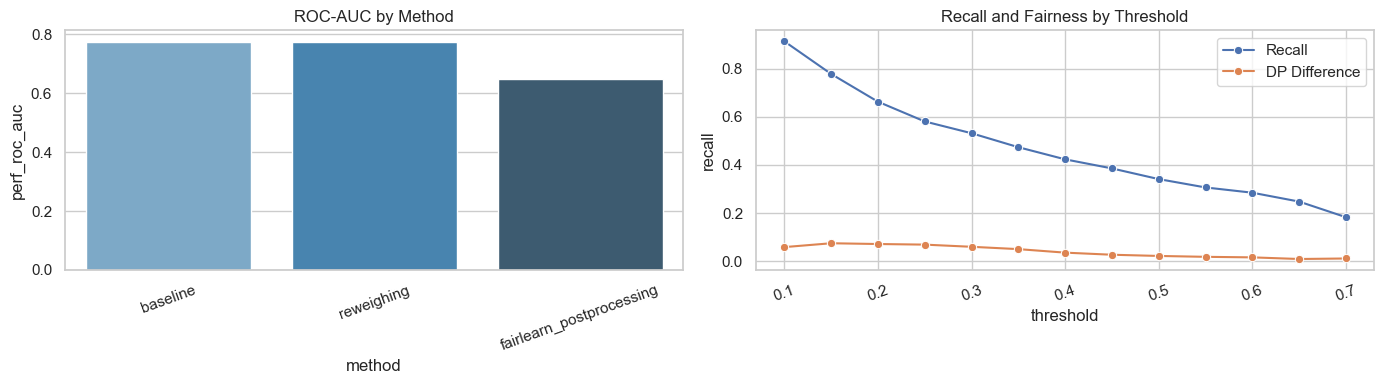

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=tradeoff, x='method', y='perf_roc_auc', ax=axes[0], hue='method', palette='Blues_d', legend=False)
axes[0].set_title('ROC-AUC by Method')
sns.lineplot(data=threshold_frontier, x='threshold', y='recall', marker='o', ax=axes[1], label='Recall')
sns.lineplot(data=threshold_frontier, x='threshold', y='demographic_parity_difference', marker='o', ax=axes[1], label='DP Difference')
axes[1].set_title('Recall and Fairness by Threshold')
for ax in axes:
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()

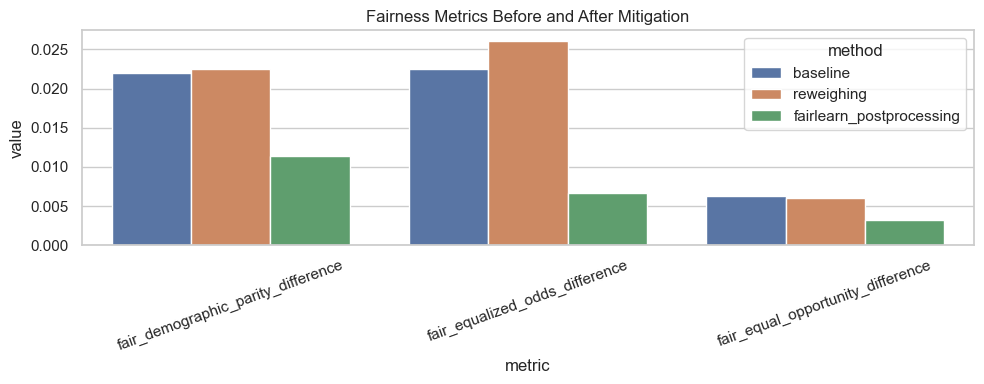

In [3]:
melted = tradeoff.melt(
    id_vars='method',
    value_vars=['fair_demographic_parity_difference', 'fair_equalized_odds_difference', 'fair_equal_opportunity_difference'],
    var_name='metric',
    value_name='value',
)
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=melted, x='metric', y='value', hue='method', ax=ax)
ax.set_title('Fairness Metrics Before and After Mitigation')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()

## Ethical interpretation

The saved results show a real tradeoff: threshold choices can improve recall while widening group diagnostics. This is why the dashboard frames the model as decision support requiring human oversight and threshold governance.